<a href="https://colab.research.google.com/github/Faisaleka21/Machine_Learning/blob/main/tugas_decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

randomstate = 23

In [ ]:
# Memuat dataset /jika format csv (;) maka ditambahkan (url,sep=';')
df = pd.read_csv('https://raw.githubusercontent.com/Faisaleka21/Machine_Learning/refs/heads/main/data_set/LK2.csv',sep=';')

# Menampilkan dataframe
df

,No,Usia,Tekanan Darah,Kolesterol,Merokok,Riwayat Keluarga,Risiko Jantung
0,1,>50,Tinggi,Tinggi,Ya,Ya,Tinggi
1,2,<50,Normal,Normal,Tidak,Tidak,Rendah
2,3,>50,Normal,Tinggi,Ya,Tidak,Tinggi
3,4,<50,Tinggi,Normal,Ya,Ya,Sedang
4,5,>50,Tinggi,Tinggi,Tidak,Ya,Tinggi
5,6,<50,Normal,Normal,Tidak,Ya,Rendah
6,7,>50,Tinggi,Normal,Ya,Ya,Tinggi
7,8,>50,Normal,Normal,Tidak,Tidak,Sedang
8,9,<50,Tinggi,Tinggi,Ya,Tidak,Sedang
9,10,>50,Tinggi,Tinggi,Ya,Tidak,Tinggi


In [ ]:
print(df.columns)

Index(['No', 'Usia', 'Tekanan Darah', 'Kolesterol', 'Merokok',
       'Riwayat Keluarga', 'Risiko Jantung'],
      dtype='object')


In [ ]:
# Mengecek ukuran dataset (baris, kolom)
df.shape

(15, 7)

In [ ]:
# Menampilkan informasi detail dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   No                15 non-null     int64 
 1   Usia              15 non-null     object
 2   Tekanan Darah     15 non-null     object
 3   Kolesterol        15 non-null     object
 4   Merokok           15 non-null     object
 5   Riwayat Keluarga  15 non-null     object
 6   Risiko Jantung    15 non-null     object
dtypes: int64(1), object(6)
memory usage: 972.0+ bytes


In [ ]:
# Mengecek jumlah nilai yang kosong (missing values) di setiap kolom
df.isna().sum()

,0
No,0
Usia,0
Tekanan Darah,0
Kolesterol,0
Merokok,0
Riwayat Keluarga,0
Risiko Jantung,0


In [ ]:
# Tambahkan ini sebelum memisahkan X dan y
# Mengubah data kategori menjadi angka

# 1. Usia: <50 jadi 0, >50 jadi 1
df['Usia'] = df['Usia'].map({'<50': 0, '>50': 1})

# 2. Tekanan Darah & Kolesterol: Normal jadi 0, Tinggi jadi 1
df['Tekanan Darah'] = df['Tekanan Darah'].map({'Normal': 0, 'Tinggi': 1})
df['Kolesterol'] = df['Kolesterol'].map({'Normal': 0, 'Tinggi': 1})

# 3. Merokok & Riwayat Keluarga: Tidak jadi 0, Ya jadi 1
df['Merokok'] = df['Merokok'].map({'Tidak': 0, 'Ya': 1})
df['Riwayat Keluarga'] = df['Riwayat Keluarga'].map({'Tidak': 0, 'Ya': 1})

# 4. Target (Risiko Jantung): Rendah=0, Sedang=1, Tinggi=2
df['Risiko Jantung'] = df['Risiko Jantung'].map({'Rendah': 0, 'Sedang': 1, 'Tinggi': 2})

print(df.isna().sum())
# Baru setelah ini kamu jalankan pemisahan X dan y
X = df.iloc[:, 1:-1] # Mulai dari indeks 1 agar kolom 'No' tidak ikut masuk
y = df.iloc[:, -1]

No                  0
Usia                0
Tekanan Darah       0
Kolesterol          0
Merokok             0
Riwayat Keluarga    0
Risiko Jantung      0
dtype: int64


In [ ]:
df

,No,Usia,Tekanan Darah,Kolesterol,Merokok,Riwayat Keluarga,Risiko Jantung
0,1,1,1,1,1,1,2
1,2,0,0,0,0,0,0
2,3,1,0,1,1,0,2
3,4,0,1,0,1,1,1
4,5,1,1,1,0,1,2
5,6,0,0,0,0,1,0
6,7,1,1,0,1,1,2
7,8,1,0,0,0,0,1
8,9,0,1,1,1,0,1
9,10,1,1,1,1,0,2


In [ ]:
print(df['Risiko Jantung'].unique())
print(df['Risiko Jantung'].isna().sum())

[2 0 1]
0


In [ ]:
# Menampilkan 5 data terakhir dari fitur (X)
x.tail ()

,No,Usia,Tekanan Darah,Kolesterol,Merokok,Riwayat Keluarga
10,11,0,0,1,0,1
11,12,1,0,0,0,1
12,13,0,1,0,0,0
13,14,1,1,0,0,0
14,15,0,0,1,0,1


In [ ]:
# Menampilkan 5 data terakhir dari target (y)
y.tail ()

,Risiko Jantung
10,1
11,1
12,0
13,1
14,1


In [ ]:
print (y.value_counts())

Risiko Jantung
1    7
2    5
0    3
Name: count, dtype: int64


In [ ]:
# Membagi data menjadi Training Set dan Test Set
X_train, X_test, y_train, y_test = train_test_split(x, y,test_size=0.3,random_state=randomstate)

print("Data train : ", len(X_train))
print("Data test  : ", len(X_test))

Data train :  10
Data test  :  5


In [ ]:
# Membuat dan melatih model Decision Tree
model = DecisionTreeClassifier(criterion='entropy',random_state=randomstate)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=23)

In [ ]:
# Melakukan prediksi menggunakan data test
y_pred = model.predict(X_test)

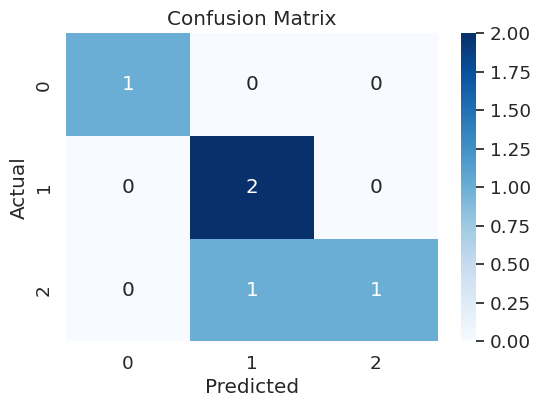

In [ ]:
# Mendapatkan nama kelas yang unik untuk label visualisasi
class_names = [str(i) for i in sorted(y_test.unique())]

# Membuat Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.set(font_scale=1.2)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Menampilkan Classification Report (Precision, Recall, F1-Score)
class_report = classification_report(y_test, y_pred,target_names=class_names, digits=4)
print("Classification Report :\n", class_report)

Classification Report :
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         1
           1     0.6667    1.0000    0.8000         2
           2     1.0000    0.5000    0.6667         2

    accuracy                         0.8000         5
   macro avg     0.8889    0.8333    0.8222         5
weighted avg     0.8667    0.8000    0.7867         5



In [ ]:
# Menampilkan Skor Akurasi Akhir
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy * 100:.2f}%")

Accuracy Score: 80.00%


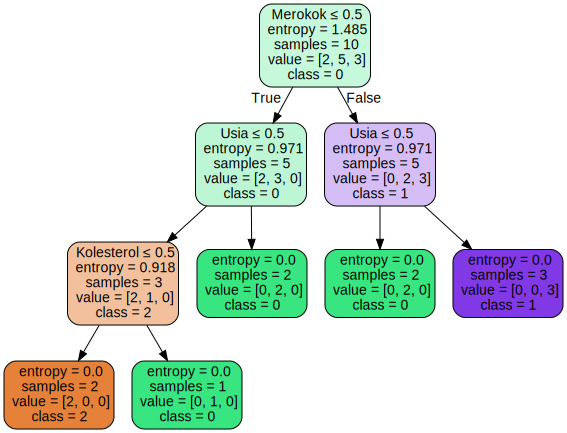

In [ ]:
# Menyiapkan nama fitur dan nama kelas untuk visualisasi pohon
feature_names = x.columns.tolist()
class_names = [str(i) for i in y.unique()]

# Mengekspor struktur pohon ke format DOT
dot_data = export_graphviz(model, out_file=None,feature_names=feature_names,class_names=class_names,filled=True, rounded=True,special_characters=True)

# Membuat grafik dari data DOT dan menyimpannya sebagai file PNG
graph = graphviz.Source(dot_data)
graph.render(filename='decision_tree', format='png', cleanup=True)
graph # Ini akan menampilkan pohon langsung di notebook

In [ ]:
# --- Membuat Tabel Perbandingan ---

# Membuat DataFrame baru untuk data pengujian
test_df = pd.DataFrame(X_test, columns=x.columns)

# Menambahkan kolom kelas aktual dan kelas hasil prediksi
test_df['Actual Class'] = y_test.values
test_df['Predicted Class'] = y_pred

# Menampilkan 5 baris pertama tabel perbandingan
test_df.head()

,No,Usia,Tekanan Darah,Kolesterol,Merokok,Riwayat Keluarga,Actual Class,Predicted Class
11,12,1,0,0,0,1,1,1
4,5,1,1,1,0,1,2,1
0,1,1,1,1,1,1,2,2
10,11,0,0,1,0,1,1,1
5,6,0,0,0,0,1,0,0


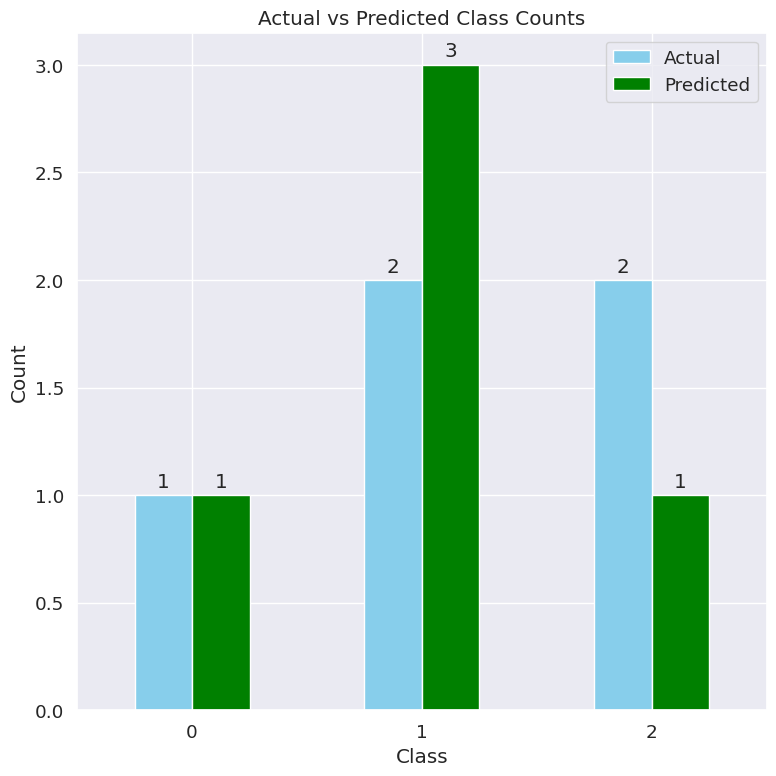

In [ ]:
# Mengelompokkan data untuk membandingkan jumlah total aktual vs prediksi
comparison_df = test_df.groupby('Actual Class').size().to_frame('Actual')
comparison_df['Predicted'] = test_df.groupby('Predicted Class').size()

# Menangani nilai kosong jika ada kelas yang tidak terprediksi sama sekali
comparison_df.fillna(0, inplace=True)
comparison_df = comparison_df.astype(int)

# Menampilkan grafik batang perbandingan
ax = comparison_df.plot(kind='bar', figsize=(8, 8), color=['skyblue', 'green'])

ax.bar_label(ax.containers[0], fmt='%d', padding=3)
ax.bar_label(ax.containers[1], fmt='%d', padding=3)

plt.title('Actual vs Predicted Class Counts')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
test_df.to_excel('CP45_Data Test & Prediction.xlsx', index=False)